# 02 — Quantization curves (WS2)

**Feeds claims C3, C5, C8, C14** — the core of the talk.

Runs the index matrix below over the WS1 fixtures (identical vectors,
identical queries, GT from `01_datasets.ipynb`) on local Milvus standalone
`v2.6.18`. 1M first; 10M for the headline curves.

Per arm: recall@10/@100 vs GT · latency p50/p99 · QPS at fixed recall
(0.90/0.95/0.99 via nprobe/ef sweep) · **actual loaded memory** (from
segment/loaded-size introspection, never estimated) · build time.

**Honesty gate (C8):** report compression two ways — vector-payload ratio
and total-loaded-footprint ratio (refine structures included). If 16–32x
with single-digit recall loss doesn't hold, the abstract number gets
reframed by end of week 2 — that decision is made from this notebook's
`results/ws2/` CSVs.

**Runtime (1M, M2-class laptop, Milvus in Docker):** ~3–5 h wall clock for
all 13 arms; ingest+build dominates. Per-arm results are cached in
`data/ws2_cache/{SCALE}/` — re-running a completed notebook is cheap, and a
crashed run resumes where it stopped. RAM: fp32 arms load ~4 GB into the
Milvus container at 1M; Docker VM needs ≥ 8 GB free.

Prereqs: notebook 01 completed at this SCALE; `make up` (asserted below);
unit tests green (`python -m unittest tests.test_quantization`); runner helpers
smoke-tested against live Milvus (`python scripts/index-footprint/smoke_ws2_runner.py`).


In [1]:
# ---- setup ------------------------------------------------------------------
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from benchlib import manifest
from benchlib.config import *  # pinned constants — single source of truth

SCALE = "1m"          # "1m" first; "10m" for headline runs
N_ROWS = SLICES[SCALE]
rng = np.random.default_rng(SEED)


In [2]:
# ---- Milvus connection (docker compose up -d first; `make up`) -------------
from pymilvus import MilvusClient, DataType

client = MilvusClient(uri=MILVUS_URI)
server_version = client.get_server_version()
print("Milvus server:", server_version)
assert MILVUS_VERSION in server_version, (
    f"expected pinned v{MILVUS_VERSION} — got {server_version}. "
    "Numbers from a different server version are not comparable.")


Milvus server: 2.6.18


In [3]:
# ---- draft index matrix (finalize params before the 1M run) ----------------
# nominal_payload_bytes: per-vector index payload used for the compression-
# ratio axis; the *measured* loaded footprint is what goes on the slide.
D = EMBED_DIM  # 1024
INDEX_MATRIX = {
    "flat_fp32":      dict(index_type="FLAT", metric_type="IP",
                           params={}, nominal_payload_bytes=4 * D),
    "hnsw_fp32":      dict(index_type="HNSW", metric_type="IP",
                           params={"M": 16, "efConstruction": 200},
                           nominal_payload_bytes=4 * D),
    "ivf_flat_fp32":  dict(index_type="IVF_FLAT", metric_type="IP",
                           params={"nlist": 4096},
                           nominal_payload_bytes=4 * D),
    "ivf_sq8":        dict(index_type="IVF_SQ8", metric_type="IP",
                           params={"nlist": 4096},
                           nominal_payload_bytes=D),               # 4x
    "ivf_pq_m512":    dict(index_type="IVF_PQ", metric_type="IP",
                           params={"nlist": 4096, "m": 512, "nbits": 8},
                           nominal_payload_bytes=512),             # 8x
    "ivf_pq_m256":    dict(index_type="IVF_PQ", metric_type="IP",
                           params={"nlist": 4096, "m": 256, "nbits": 8},
                           nominal_payload_bytes=256),             # 16x
    "ivf_pq_m128":    dict(index_type="IVF_PQ", metric_type="IP",
                           params={"nlist": 4096, "m": 128, "nbits": 8},
                           nominal_payload_bytes=128),             # 32x
    "rabitq":         dict(index_type="IVF_RABITQ", metric_type="IP",
                           params={"nlist": 4096},
                           nominal_payload_bytes=D // 8),          # 32x payload
    # refine arms share the binary payload + an SQ8 refine copy (measure it!)
    **{f"rabitq_refine_sq8_k{k}":
           dict(index_type="IVF_RABITQ", metric_type="IP",
                params={"nlist": 4096, "refine": True,
                        "refine_type": "SQ8"},
                search_extra={"refine_k": k},
                nominal_payload_bytes=D // 8 + D)
       for k in (1, 2, 5, 10)},
}
RECALL_TARGETS = [0.90, 0.95, 0.99]
NPROBE_SWEEP = [1, 2, 4, 8, 16, 32, 64, 128, 256]
EF_SWEEP = [16, 32, 64, 128, 256, 512]
len(INDEX_MATRIX)


12

### Methodology (locked before the run — see results/index-footprint.md for findings)

1. **Correctness gate first.** The FLAT arm is ingested, searched, and scored
   against the WS1 exact ground truth *before any other arm runs*. Recall@10
   and @100 must be ≥ 0.999 (the only tolerated loss source is sub-1e-6
   near-ties at the @100 boundary). If the gate fails the notebook raises —
   every downstream number would be poisoned.
2. **Identical data per arm.** Same fp32 memmap, same insert order (PK = row
   index, so GT indices compare directly), same 10k GT queries. Fresh
   collection per arm, dropped afterwards — no index state leaks.
3. **Measured memory, never estimated.** `benchlib.quantization.measure_footprint`,
   called *after* the arm's query workload (Milvus v2.6 materializes serving
   state lazily). `loaded_bytes` = built-index file bytes for exactly the
   build_ids referenced by the collection's loaded sealed segments
   (`:9091/api/v1/_qn/segments` → `du` of `files/index_files/{build_id}` in
   the MinIO container — what the query node deserializes to serve)
   + this collection's mmapped chunk-cache file bytes
   (`/var/lib/milvus/data/cache`, how FLAT serves raw vectors)
   + sealed-segment heap `mem_size` (`:9091/api/v1/_qn/segments`).
   The coarser datacoord metric `stored_index_files_size` also counts stale
   pre-compaction index generations until GC (~2x overcount — observed
   directly on the HNSW arm) and is kept as an audit field only, alongside
   process-RSS deltas (allocator retention makes those 2–3x noisy). The
   exact accounting string is committed in `benchlib.quantization.MEASURE_API`.
4. **Separate timing runs.** Latency p50/p99: sequential single-query
   requests, 100 warm-ups then 500 timed, at `limit=10`. QPS: a separate
   concurrent run (8 threads × 2000 single-query requests, thread count in
   the CSV). Neither is derived from the other. Recall@10 comes from a
   `limit=10` search and recall@100 from a `limit=100` search — for refine
   arms the rerank pool is `refine_k × limit`, so recall@k must be measured
   at serving `limit=k` to be honest. (HNSW requires `ef ≥ limit`, so
   recall@100 is null for ef < 100.)
5. **Sweeps.** nprobe ∈ {1..256} for IVF-family arms, ef ∈ {16..512} for
   HNSW, refine_k ∈ {1,2,5,10} as separate arms per the index matrix. One
   CSV row per (arm, sweep-point).
6. A failed arm (e.g. a PQ config Milvus rejects) writes
   `data/ws2_cache/{SCALE}/{arm}.failed.json` and the run continues — the
   failure is reported in results/index-footprint.md, parameters are never swapped
   silently.


In [4]:
# ---- fixtures + preflight ---------------------------------------------------
from benchlib.quantization import (
    build_index, concurrent_qps, ensure_fresh_collection, ingest,
    latency_summary, measure_footprint, milvus_rss_bytes, payload_compression,
    pick_best_sweep_points, recall_at_k, search_ids, timed_sequential,
)

CACHE_DIR = DATA_DIR / "ws2_cache" / SCALE
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_WS2 = RESULTS_DIR / "ws2"
RESULTS_WS2.mkdir(parents=True, exist_ok=True)

corpus = np.load(slice_path(SCALE), mmap_mode="r")
assert corpus.shape == (N_ROWS, EMBED_DIM), corpus.shape

queries = np.load(DATA_DIR / "queries_gt_emb.npy")
assert queries.shape == (N_GT_QUERIES, EMBED_DIM), queries.shape
qn = np.linalg.norm(queries, axis=1)
assert np.allclose(qn, 1.0, atol=1e-3), "GT queries must be L2-normalized"

gtz = np.load(gt_path(SCALE))
gt_indices = gtz["gt_indices"]
assert gt_indices.shape == (N_GT_QUERIES, GT_TOP_K), gt_indices.shape
assert gt_indices.max() < N_ROWS  # GT was computed over this exact slice

# corpus rows are already L2-normalized (WS1); spot-check a sample
sample = corpus[rng.choice(N_ROWS, 1000, replace=False)]
assert np.allclose(np.linalg.norm(sample, axis=1), 1.0, atol=1e-3)

print(f"fixtures OK: corpus {corpus.shape} memmap, {N_GT_QUERIES} queries, "
      f"GT top-{GT_TOP_K}; cache -> {CACHE_DIR.relative_to(REPO_ROOT)}")


fixtures OK: corpus (1000000, 1024) memmap, 10000 queries, GT top-100; cache -> data/ws2_cache/1m


In [5]:
# ---- runner: one full ingest→build→load→measure cycle per arm, cached ------
import json
import traceback

N_WARMUP, N_TIMED = 100, 500          # sequential latency run
QPS_THREADS, N_QPS_QUERIES = 8, 2000  # separate concurrent throughput run


def sweep_points(spec):
    """[(sweep_param, sweep_value, search_params)] for one arm."""
    it = spec["index_type"]
    if it == "FLAT":
        return [("none", 0, {})]
    if it == "HNSW":
        return [("ef", ef, {"ef": ef}) for ef in EF_SWEEP]
    extra = spec.get("search_extra", {})
    return [("nprobe", n, {"nprobe": n, **extra}) for n in NPROBE_SWEEP]


def run_arm(arm, spec):
    """Full cycle for one arm; cached in CACHE_DIR/{arm}.json (resumable).
    Failures are recorded to {arm}.failed.json and return None — the run
    continues; parameters are never swapped silently."""
    cache_f = CACHE_DIR / f"{arm}.json"
    if cache_f.exists():
        print(f"[{arm}] cached — skipping")
        return json.loads(cache_f.read_text())

    coll = f"ws2_{SCALE}_{arm}"
    t_arm = time.time()
    try:
        ensure_fresh_collection(client, coll, EMBED_DIM)
        ingest_s = ingest(client, coll, corpus)
        print(f"[{arm}] ingested {N_ROWS} rows in {ingest_s:.0f}s")
        build_s = build_index(client, coll, spec["index_type"], spec["params"])
        print(f"[{arm}] index built in {build_s:.0f}s")
        rss0 = milvus_rss_bytes()
        client.load_collection(coll)

        rows = []
        for pname, pval, params in sweep_points(spec):
            pred10 = search_ids(client, coll, queries, 10, params)
            r10 = recall_at_k(pred10, gt_indices, 10)
            try:  # HNSW: ef < limit is rejected → recall@100 stays null
                pred100 = search_ids(client, coll, queries, GT_TOP_K, params)
                r100 = recall_at_k(pred100, gt_indices, GT_TOP_K)
            except Exception:
                r100 = None
            lat = latency_summary(timed_sequential(
                client, coll, queries, params, N_WARMUP, N_TIMED, limit=10))
            qps = concurrent_qps(client, coll, queries, params,
                                 QPS_THREADS, N_QPS_QUERIES, limit=10)
            rows.append(dict(
                scale=SCALE, arm=arm, index_type=spec["index_type"],
                sweep_param=pname, sweep_value=pval,
                refine_k=spec.get("search_extra", {}).get("refine_k"),
                recall_at_10=r10, recall_at_100=r100,
                p50_ms=lat["p50_ms"], p99_ms=lat["p99_ms"],
                qps=qps, qps_threads=QPS_THREADS,
                build_seconds=build_s, ingest_seconds=ingest_s,
                nominal_payload_bytes=spec["nominal_payload_bytes"],
                n_rows=N_ROWS))
            print(f"[{arm}] {pname}={pval}: r@10={r10:.4f} "
                  f"r@100={'—' if r100 is None else f'{r100:.4f}'} "
                  f"p50={lat['p50_ms']:.2f}ms qps={qps:.0f}")

        # footprint AFTER the workload — v2.6 materializes serving state lazily
        m = measure_footprint(client, coll, rss0)
        for row in rows:
            row.update({k: m[k] for k in (
                "loaded_bytes", "index_files_bytes", "chunk_cache_bytes",
                "segment_heap_bytes")})
        result = {"arm": arm, "rows": rows, "measure": m,
                  "arm_wall_seconds": time.time() - t_arm}
        cache_f.write_text(json.dumps(result, indent=1))
        print(f"[{arm}] done in {result['arm_wall_seconds']:.0f}s; "
              f"loaded {m['loaded_bytes']/2**20:.0f} MiB")
        return result
    except Exception as e:
        (CACHE_DIR / f"{arm}.failed.json").write_text(json.dumps(
            {"arm": arm, "error": repr(e),
             "traceback": traceback.format_exc()}, indent=1))
        print(f"[{arm}] FAILED — recorded, continuing: {e!r}")
        return None
    finally:
        try:
            client.release_collection(coll)
            client.drop_collection(coll)
        except Exception:
            pass


In [6]:
# ---- correctness gate: FLAT vs WS1 exact ground truth (RED test) ------------
# Runs before any other arm. If FLAT-on-Milvus disagrees with the WS1
# brute-force GT beyond near-tie noise, the recall pipeline is broken and
# every downstream number would be poisoned — so this raises, hard.
gate = run_arm("flat_fp32", INDEX_MATRIX["flat_fp32"])
if gate is None:
    raise RuntimeError("FLAT arm failed to run — cannot proceed. "
                       f"See {CACHE_DIR}/flat_fp32.failed.json")

flat_row = gate["rows"][0]
GATE_MIN = 0.999
print(f"FLAT gate: recall@10={flat_row['recall_at_10']:.6f} "
      f"recall@100={flat_row['recall_at_100']:.6f} (threshold {GATE_MIN})")
if flat_row["recall_at_10"] < GATE_MIN or flat_row["recall_at_100"] < GATE_MIN:
    raise RuntimeError(
        "FLAT correctness gate FAILED — do not trust any arm results. "
        f"recall@10={flat_row['recall_at_10']}, "
        f"recall@100={flat_row['recall_at_100']}. Debug before proceeding "
        "(insert-order/PK mismatch? wrong metric? wrong GT file?)")
print("gate PASSED — proceeding to the full index matrix")


[flat_fp32] cached — skipping
FLAT gate: recall@10=1.000000 recall@100=0.999994 (threshold 0.999)
gate PASSED — proceeding to the full index matrix


In [7]:
# ---- run the remaining arms (each cached; ~3-5h total at 1M) ----------------
t_matrix = time.time()
for arm, spec in INDEX_MATRIX.items():
    if arm == "flat_fp32":
        continue  # gate cell above already ran it
    run_arm(arm, spec)
print(f"index matrix wall clock this session: {time.time() - t_matrix:.0f}s")

failed = sorted(p.stem.replace(".failed", "")
                for p in CACHE_DIR.glob("*.failed.json"))
done = sorted(p.stem for p in CACHE_DIR.glob("*.json")
              if not p.name.endswith(".failed.json"))
print(f"arms complete: {len(done)}/{len(INDEX_MATRIX)}: {done}")
if failed:
    print(f"arms FAILED (recorded, see cache dir): {failed}")


[hnsw_fp32] cached — skipping
[ivf_flat_fp32] cached — skipping
[ivf_sq8] cached — skipping
[ivf_pq_m512] cached — skipping
[ivf_pq_m256] cached — skipping
[ivf_pq_m128] cached — skipping
[rabitq] cached — skipping
[rabitq_refine_sq8_k1] cached — skipping
[rabitq_refine_sq8_k2] cached — skipping
[rabitq_refine_sq8_k5] cached — skipping
[rabitq_refine_sq8_k10] cached — skipping
index matrix wall clock this session: 0s
arms complete: 12/12: ['flat_fp32', 'hnsw_fp32', 'ivf_flat_fp32', 'ivf_pq_m128', 'ivf_pq_m256', 'ivf_pq_m512', 'ivf_sq8', 'rabitq', 'rabitq_refine_sq8_k1', 'rabitq_refine_sq8_k10', 'rabitq_refine_sq8_k2', 'rabitq_refine_sq8_k5']


In [8]:
# ---- results/ws2/curves_{SCALE}.csv — the ONLY cell that writes it ----------
all_rows = []
for arm in INDEX_MATRIX:  # matrix order, not glob order
    cache_f = CACHE_DIR / f"{arm}.json"
    if cache_f.exists():
        all_rows.extend(json.loads(cache_f.read_text())["rows"])

curves = pd.DataFrame(all_rows)
curves["payload_compression"] = curves.nominal_payload_bytes.map(
    lambda b: payload_compression(b, EMBED_DIM))
flat_loaded = int(curves.loc[curves.arm == "flat_fp32", "loaded_bytes"].iloc[0])
curves["footprint_compression_vs_flat"] = flat_loaded / curves.loaded_bytes

curves_path = RESULTS_WS2 / f"curves_{SCALE}.csv"
curves.to_csv(curves_path, index=False)
print(f"wrote {curves_path.relative_to(REPO_ROOT)}: {len(curves)} rows, "
      f"{curves.arm.nunique()} arms")
curves.groupby("arm", sort=False).agg(
    points=("sweep_value", "size"), best_r10=("recall_at_10", "max"),
    loaded_MiB=("loaded_bytes", lambda b: b.iloc[0] / 2**20))


wrote results/ws2/curves_1m.csv: 97 rows, 12 arms


,points,best_r10,loaded_MiB
arm,,,
flat_fp32,1,1.00000,3960.371248
hnsw_fp32,6,0.99940,4104.343899
ivf_flat_fp32,9,0.99521,4062.672037
ivf_sq8,9,0.99031,1129.320459
ivf_pq_m512,9,0.94396,659.734549
ivf_pq_m256,9,0.81946,432.449400
ivf_pq_m128,9,0.60175,314.320477
rabitq,9,0.74109,290.632975
rabitq_refine_sq8_k1,9,0.95457,1272.543114


In [9]:
# ---- results/ws2/c8_verdict_{SCALE}.csv — the ONLY cell that writes it ------
# For each recall@10 target: best sweep point per arm (max QPS among points
# meeting the target; if none meet it, the arm's max-recall point with
# met_target=False). Payload compression AND measured footprint compression
# side by side — the C8 honesty accounting.
verdict = pick_best_sweep_points(curves, RECALL_TARGETS)
verdict = verdict[[
    "target", "met_target", "arm", "index_type", "sweep_param", "sweep_value",
    "refine_k", "recall_at_10", "recall_at_100", "p50_ms", "p99_ms", "qps",
    "qps_threads", "payload_compression", "footprint_compression_vs_flat",
    "loaded_bytes", "index_files_bytes", "chunk_cache_bytes",
    "nominal_payload_bytes", "build_seconds", "n_rows", "scale",
]].sort_values(["target", "footprint_compression_vs_flat"],
               ascending=[True, False]).reset_index(drop=True)

verdict_path = RESULTS_WS2 / f"c8_verdict_{SCALE}.csv"
verdict.to_csv(verdict_path, index=False)
print(f"wrote {verdict_path.relative_to(REPO_ROOT)}")

with pd.option_context("display.width", 160, "display.max_columns", 20):
    print(verdict[["target", "met_target", "arm", "sweep_value", "refine_k",
                   "recall_at_10", "p50_ms", "qps", "payload_compression",
                   "footprint_compression_vs_flat"]].round(3).to_string())


wrote results/ws2/c8_verdict_1m.csv
    target  met_target                    arm  sweep_value  refine_k  recall_at_10  p50_ms      qps  payload_compression  footprint_compression_vs_flat
0     0.90       False                 rabitq          256       NaN         0.741  66.188   25.087               32.000                         13.627
1     0.90       False            ivf_pq_m128          256       NaN         0.602  15.846  106.410               32.000                         12.600
2     0.90       False            ivf_pq_m256          256       NaN         0.819  20.663   51.853               16.000                          9.158
3     0.90        True            ivf_pq_m512           64       NaN         0.923   6.463  246.418                8.000                          6.003
4     0.90        True                ivf_sq8           16       NaN         0.938   4.975  292.020                4.000                          3.507
5     0.90        True   rabitq_refine_sq8_k5       

wrote results/ws2/chart_recall_vs_compression_1m.png


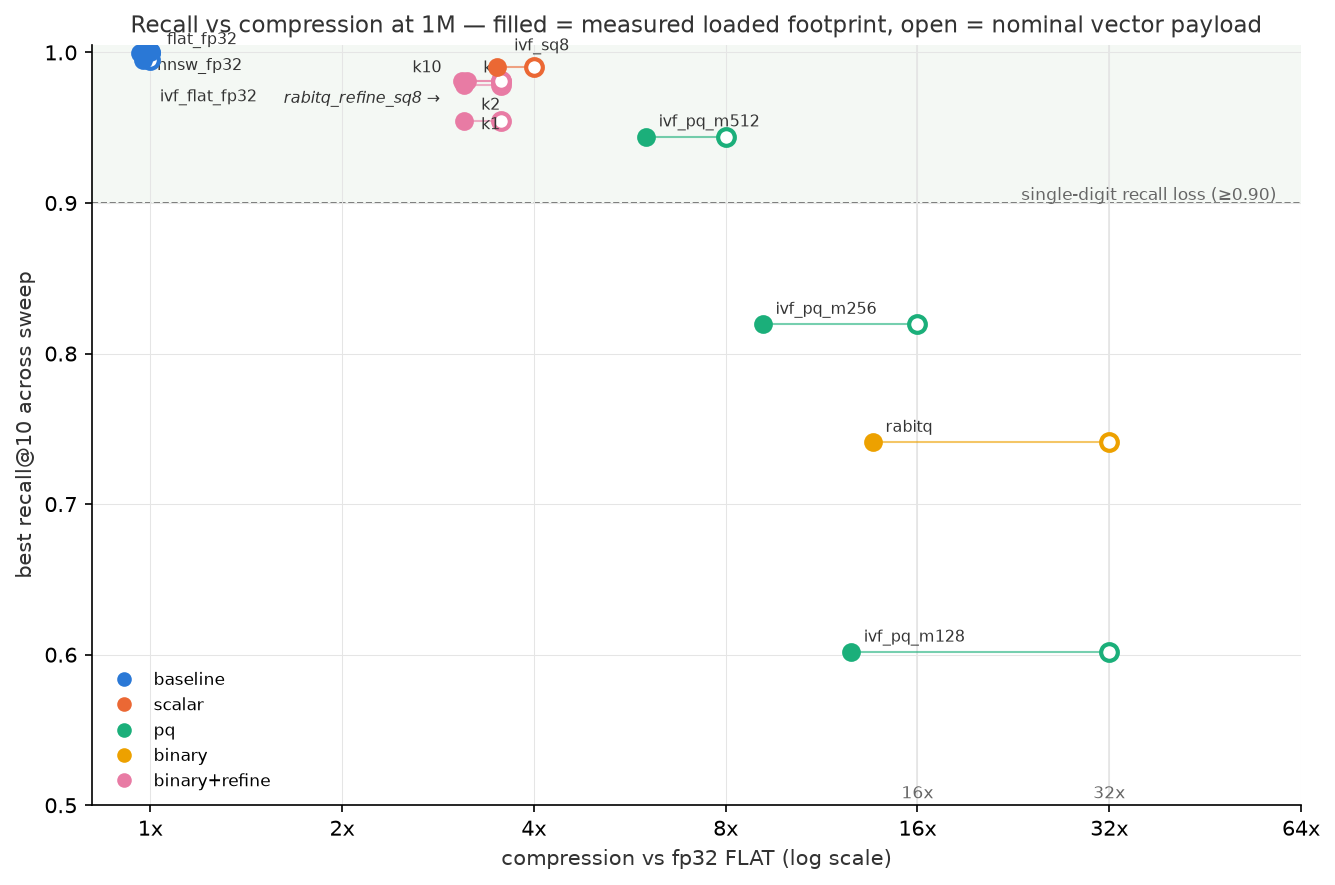

In [10]:
# ---- chart: recall vs compression (payload AND measured footprint) ----------
import matplotlib.pyplot as plt

# categorical slots (validated palette, fixed order) assigned per arm family
FAMILY_COLOR = {"baseline": "#2a78d6", "scalar": "#eb6834", "pq": "#1baf7a",
                "binary": "#eda100", "binary+refine": "#e87ba4"}
INK, INK2, GRID = "#333333", "#666666", "#e5e5e5"


def arm_family(arm):
    if arm.startswith("rabitq_refine"):
        return "binary+refine"
    if arm == "rabitq":
        return "binary"
    if arm.startswith("ivf_pq"):
        return "pq"
    if arm == "ivf_sq8":
        return "scalar"
    return "baseline"


# short labels + per-arm offsets so the dense top-left cluster stays legible
# (refine arms are colored by family, so "k1".."k10" is unambiguous)
LABELS = {f"rabitq_refine_sq8_k{k}": f"k{k}" for k in (1, 2, 5, 10)}
OFFSETS = {"flat_fp32": (8, 4), "hnsw_fp32": (8, -8), "ivf_flat_fp32": (8, -20),
           "ivf_sq8": (8, 8), "rabitq_refine_sq8_k1": (8, -4),
           "rabitq_refine_sq8_k2": (8, -12), "rabitq_refine_sq8_k5": (8, 4),
           "rabitq_refine_sq8_k10": (-24, 4)}

best = (curves.groupby("arm", sort=False)
        .apply(lambda g: g.loc[g.recall_at_10.idxmax()], include_groups=False)
        .reset_index())

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.axhspan(0.90, 1.005, color="#f4f8f4", zorder=0)
ax.axhline(0.90, color=INK2, lw=0.8, ls="--", zorder=1)
ax.text(0.98, 0.902, "single-digit recall loss (≥0.90)", ha="right",
        color=INK2, fontsize=8, transform=ax.get_yaxis_transform())
for x in (16, 32):
    ax.axvline(x, color=GRID, lw=0.8, zorder=1)
    ax.text(x, 0.502, f"{x}x", ha="center", va="bottom", color=INK2, fontsize=8)

for _, r in best.iterrows():
    c = FAMILY_COLOR[arm_family(r.arm)]
    ax.plot([r.payload_compression, r.footprint_compression_vs_flat],
            [r.recall_at_10] * 2, color=c, lw=1, alpha=0.6, zorder=2)
    ax.plot(r.payload_compression, r.recall_at_10, "o", mfc="white", mec=c,
            ms=8, mew=2, zorder=3)
    ax.plot(r.footprint_compression_vs_flat, r.recall_at_10, "o", color=c,
            ms=8, zorder=4)
    ax.annotate(LABELS.get(r.arm, r.arm),
                (r.footprint_compression_vs_flat, r.recall_at_10),
                textcoords="offset points",
                xytext=OFFSETS.get(r.arm, (6, 5)), fontsize=7.5, color=INK)
ax.text(1.62, 0.9665, "rabitq_refine_sq8 →", fontsize=7.5, color=INK,
        ha="left", style="italic")

ax.set_xscale("log", base=2)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64])
ax.set_xticklabels([f"{t}x" for t in [1, 2, 4, 8, 16, 32, 64]])
ax.set_xlabel("compression vs fp32 FLAT (log scale)", color=INK)
ax.set_ylabel("best recall@10 across sweep", color=INK)
ax.set_ylim(0.5, 1.005)
ax.set_title(f"Recall vs compression at {SCALE.upper()} — filled = measured "
             "loaded footprint, open = nominal vector payload", color=INK,
             fontsize=11)
ax.grid(True, color=GRID, lw=0.5, zorder=0)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=f)
           for f, c in FAMILY_COLOR.items()]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
chart1_path = RESULTS_WS2 / f"chart_recall_vs_compression_{SCALE}.png"
fig.savefig(chart1_path)
print(f"wrote {chart1_path.relative_to(REPO_ROOT)}")
plt.show()


wrote results/ws2/chart_refine_ablation_1m.png


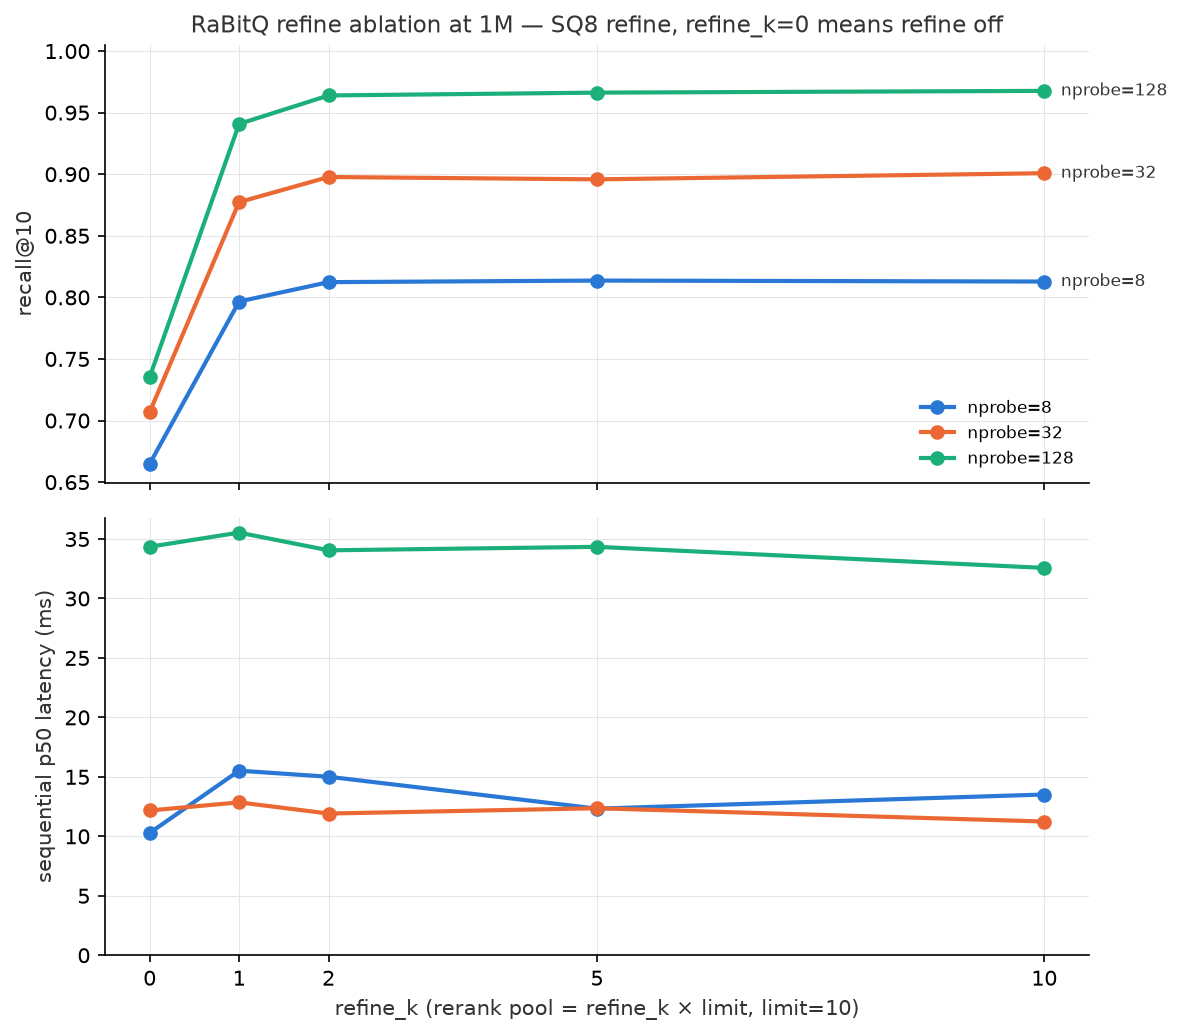

In [11]:
# ---- chart: refine_k ablation (C5/C14 — where refinement does the work) -----
# Two stacked panels sharing x (never a dual-axis chart): recall@10 on top,
# sequential p50 latency below. refine_k=0 is the plain rabitq arm.
ABLATION_NPROBES = [8, 32, 128]           # 3 series = all-pairs-safe palette cap
NPROBE_COLOR = dict(zip(ABLATION_NPROBES, ["#2a78d6", "#eb6834", "#1baf7a"]))

refine_arms = {0: "rabitq", **{k: f"rabitq_refine_sq8_k{k}"
                               for k in (1, 2, 5, 10)}}
ab = curves[curves.arm.isin(refine_arms.values())
            & curves.sweep_value.isin(ABLATION_NPROBES)].copy()
arm_to_k = {v: k for k, v in refine_arms.items()}
ab["k"] = ab.arm.map(arm_to_k)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True)
for nprobe in ABLATION_NPROBES:
    g = ab[ab.sweep_value == nprobe].sort_values("k")
    c = NPROBE_COLOR[nprobe]
    ax1.plot(g.k, g.recall_at_10, "-o", color=c, lw=2, ms=6,
             label=f"nprobe={nprobe}")
    ax2.plot(g.k, g.p50_ms, "-o", color=c, lw=2, ms=6)
    last = g.iloc[-1]
    ax1.annotate(f"nprobe={nprobe}", (last.k, last.recall_at_10),
                 textcoords="offset points", xytext=(8, 0), fontsize=8,
                 color=INK, va="center")

ax1.set_ylabel("recall@10", color=INK)
ax1.set_ylim(top=1.005)
ax1.legend(frameon=False, fontsize=8, loc="lower right")
ax1.set_title(f"RaBitQ refine ablation at {SCALE.upper()} — SQ8 refine, "
              "refine_k=0 means refine off", color=INK, fontsize=11)
ax2.set_ylabel("sequential p50 latency (ms)", color=INK)
ax2.set_xlabel("refine_k (rerank pool = refine_k × limit, limit=10)", color=INK)
ax2.set_ylim(bottom=0)
ax2.set_xticks(list(refine_arms))
for ax in (ax1, ax2):
    ax.grid(True, color=GRID, lw=0.5, zorder=0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
chart2_path = RESULTS_WS2 / f"chart_refine_ablation_{SCALE}.png"
fig.savefig(chart2_path)
print(f"wrote {chart2_path.relative_to(REPO_ROOT)}")
plt.show()


## 10M — the headline scale (C3/C8 final verdict)

Self-contained section: everything below uses `_10`-suffixed variables and
`data/ws2_cache/10m/`; the 1M cells above are untouched (and cache-skip on
re-execution). Same locked methodology as 1M except where a decision below
says otherwise — every deviation is labeled per-row in the CSV.

**Runtime: ~30–40 h wall clock** (est. from 1M sweep timings ×10 per nprobe
unit). Per-arm caches make it interruptible/resumable; arms run in talk-
priority order so the critical ones land first. RAM: largest in-memory
index is SQ8 ≈ 11 GiB (fits the 31.3 GiB Docker VM); disk peak ≈ 90–100 GB
in `volumes/` — watched per-arm with a 25 GB free-space floor. Milvus
volumes must be reset before the run (Woodpecker WAL never truncates:
measured ≈1× ingested bytes, surviving drops, GC, and restarts).

### Decision 1 — fp32 baselines don't fit
10M × 1024d × 4 B = **40.96 GB raw fp32** vs a 31.3 GiB Docker VM on a
32 GiB host: bumping VM memory is physically impossible, so in-RAM fp32
arms are out. Resolution:
- **One fp32 reference runs locally: `ivf_flat_fp32` with `mmap.enabled=true`**
  (index files mapped from disk, not deserialized to heap). Recall is
  unaffected by mmap — proven bit-identical in the A/B below (cycle 4 vs 5);
  latency/QPS mean something different when disk-backed, so the arm carries
  `mmap=True` in every CSV row and its latency is quoted only with that
  label. Clean in-RAM fp32 latency baselines were never measured: they
  were deferred to a Zilliz Cloud run that was cancelled and never
  executed, so the mmap'd arm above is the only fp32 latency reference
  at this scale. `flat_fp32` and `hnsw_fp32` are **pruned** (FLAT can't
  scan 41 GB
  per query from disk at usable speed; a page-thrashing mmap'd HNSW graph
  walk measures the SSD, not the index).
- **Footprint denominator at 10M is analytic**: raw fp32 bytes
  (40.96 GB), *not* a measured FLAT load. Empirical justification: at 1M the
  FLAT arm's measured loaded bytes equaled raw vector bytes exactly
  (3906 MiB chunk-cache = 1M×1024×4 B; heap excluded), so the analytic
  denominator is the measured one.
- The correctness gate can't be a FLAT arm either → replaced by the
  **offline SQ8 expectation gate** (cell below): `ivf_sq8` at
  `nprobe = nlist = 4096` (full scan — IVF cluster pruning disabled, so the
  only recall loss left is SQ8 quantization; also segment-layout-invariant)
  must agree within ±0.002 with an offline exact-scan over SQ8-dequantized
  vectors, computed against the WS1 GT on the same paired 500-query subset.

### Decision 2 — one ingested collection, indexes cycled, segment set frozen
Fresh-collection-per-arm at 10M ≈ 12 × ~40 min ingests plus 12 × WAL
amplification — days of overhead and a disk blowout. The 10M run instead
ingests **one collection** (`ws2_10m_shared`), forces **compaction to
completion, then freezes the segment set** (no writes afterwards), and
cycles `release → drop_index → create_index → load` per arm.

The A/B verification at 1M (`scripts/index-footprint/verify_shared_collection_ab.py`,
cached in `_ab_verification.json`) surfaced two methodological facts that
now shape the protocol — both would have silently skewed the 10M numbers:
1. **Background compaction changes recall.** The first A/B attempt (no
   freeze) failed rebuild-identity: sq8 rebuilt 40 min after its first
   build lost ~1% recall@10 at fixed nprobe, because compaction had merged
   the sealed segments and per-segment kmeans saw different training sets.
   Hence compact-then-freeze before any arm builds; with the set frozen,
   the rebuild must reproduce the first build **exactly** (deterministic
   kmeans on identical segments) — asserted below as a hard gate.
2. **Two fresh ingests of identical data already differ** by ±0.0024
   recall@10 at fixed nprobe (segment-boundary nondeterminism), so
   "identical to the 1M fresh-collection numbers" is not achievable by ANY
   strategy, including re-running the 1M methodology itself. Recorded
   corollary for ALL WS2 analysis: cross-arm recall gaps below ~0.01
   (ingest variance + compaction-state difference) are within measurement
   noise and are not cited as findings.
The A/B also proves chunk-cache stays empty across cycles (footprint
accounting clean) and that mmap'd serving returns bit-identical results
(cycles 4 vs 5). Identical data and PK-order are preserved by construction
(single ingest, PK = GT row index).
Bonus: the four refine arms share one physical index (`refine_k` is
search-time), so the refine family is **one build, four sub-arm sweeps**.

### Decision 3 — pruned matrix + measurement budget
1M wall-clocks ×10 per nprobe unit price a naive full matrix at ~80+ h.
Pruned/kept (recorded here and in results/index-footprint.md — no silent gaps):

| Arm | 10M status | Why |
|---|---|---|
| ivf_sq8 | **kept**, nprobe→512 (extended) | headline arm; margin above 0.990 |
| rabitq_refine_sq8_k2 | **kept**, nprobe→1024 (extended) | C8 core; recall-ceiling question |
| rabitq | **kept**, nprobe→256 | 32x-payload anchor; refine_k=0 ablation point |
| ivf_flat_fp32 (mmap) | **kept**, nprobe→256 | Decision-1 fp32 reference |
| ivf_pq_m256 / m128 | **kept**, nprobe→256 | 16x/32x payload collapse points |
| rabitq_refine_sq8_k5 | **kept**, nprobe ∈ {256,512,1024} | ceiling probe above k2 |
| rabitq_refine_sq8_k1/k10 | single point (nprobe=256) | 10M ablation anchors, same build |
| flat_fp32, hnsw_fp32 | **pruned** | don't fit (Decision 1) |
| ivf_pq_m512 | **pruned** | ~9 h; dominated by sq8 (4x, higher recall) at 1M — adds no talk claim |

Measurement budget (each labeled per-row in the CSV):
- **recall query counts**: 10k queries at decision-relevant points; the
  deterministic first-2000 subset at extended (512/1024) and low-nprobe
  points. Paired-subset recalls are exact for that subset (no sampling
  noise in any A-vs-B comparison on the same subset); cross-checks vs the
  10k values happen where both exist at 1M.
- **merged recall pass** for non-refine arms: one `limit=100` search gives
  recall@100 and recall@10 (top-10 prefix — identical ranking, same scan).
  Refine arms keep separate `limit=10` / `limit=100` passes because the
  rerank pool is `refine_k × limit` (1M methodology note #4); their
  recall@100 is measured only at nprobe ∈ {64, 256} (2k queries).
- **sequential latency skipped at refine nprobe ≥ 512** (rows carry null
  p50/p99): those points exist to answer "is 0.99 reachable and at what
  throughput", so QPS is kept (n=800 there, 8 threads as always).
- per-arm wall-clock budgets abort a pathologically slow arm between sweep
  points (partial rows kept, abort recorded in the arm cache).


In [12]:
# ---- 10M: fixtures + config (self-contained; 1M cells above untouched) -----
import shutil

SCALE_10 = "10m"
N_ROWS_10 = SLICES[SCALE_10]
CACHE_10 = DATA_DIR / "ws2_cache" / SCALE_10
CACHE_10.mkdir(parents=True, exist_ok=True)
SHARED_COLL = "ws2_10m_shared"

# Decision-1 denominator: analytic raw fp32 bytes (empirically == measured
# FLAT at 1M, see the markdown cell above).
RAW_FP32_BYTES_10 = N_ROWS_10 * EMBED_DIM * 4  # 40.96 GB

DISK_FLOOR_BYTES = 25 * 2**30   # skip-with-record any arm below this free

corpus_10 = np.load(slice_path(SCALE_10), mmap_mode="r")
assert corpus_10.shape == (N_ROWS_10, EMBED_DIM), corpus_10.shape

gt_10 = np.load(gt_path(SCALE_10))["gt_indices"]
assert gt_10.shape == (N_GT_QUERIES, GT_TOP_K), gt_10.shape
assert gt_10.max() < N_ROWS_10

# same 10k GT queries as 1M (loaded in the 1M fixtures cell)
assert queries.shape == (N_GT_QUERIES, EMBED_DIM)

sample_10 = corpus_10[rng.choice(N_ROWS_10, 1000, replace=False)]
assert np.allclose(np.linalg.norm(sample_10, axis=1), 1.0, atol=1e-3)

free_gb = shutil.disk_usage(REPO_ROOT).free / 2**30
print(f"10M fixtures OK: corpus {corpus_10.shape} memmap, GT top-{GT_TOP_K}, "
      f"denominator {RAW_FP32_BYTES_10/2**30:.2f} GiB analytic, "
      f"disk free {free_gb:.0f} GiB")


10M fixtures OK: corpus (10000000, 1024) memmap, GT top-100, denominator 38.15 GiB analytic, disk free 332 GiB


In [13]:
# ---- 10M: pruned index matrix + per-point measurement plan -----------------
# Point spec: nprobe · n_recall (recall@10 query count) · r100_n (recall@100
# query count; None = not measured at this point; ignored for merged-mode
# arms where the limit=100 pass serves both) · lat (sequential latency
# run?) · qps_n (concurrent-throughput query count, 8 threads).
def P(nprobe, n_recall=10_000, r100_n=None, lat=True, qps_n=2000):
    return dict(nprobe=nprobe, n_recall=n_recall, r100_n=r100_n,
                lat=lat, qps_n=qps_n)


N2K = 2000  # deterministic first-2000 paired subset

INDEX_MATRIX_10 = {
    # -- priority 1: headline scalar arm (extended sweep to 512) --
    "ivf_sq8": dict(
        index_type="IVF_SQ8", params={"nlist": 4096},
        nominal_payload_bytes=EMBED_DIM, recall_mode="merged",
        points=[P(16, N2K), P(32, N2K), P(64), P(128), P(256), P(512)],
        time_budget_s=9 * 3600),
    # -- priority 2/7/anchors: the refine family — ONE build, sub-arm sweeps
    #    (refine_k is search-time; sub-arms share the physical index) --
    "rabitq_refine_sq8": dict(
        index_type="IVF_RABITQ",
        params={"nlist": 4096, "refine": True, "refine_type": "SQ8"},
        nominal_payload_bytes=EMBED_DIM // 8 + EMBED_DIM,
        recall_mode="separate",
        sub_arms={
            2: dict(points=[P(32, N2K), P(64, r100_n=N2K), P(128),
                            P(256, r100_n=N2K),
                            P(512, N2K, lat=False, qps_n=800),
                            P(1024, N2K, lat=False, qps_n=800)],
                    time_budget_s=11 * 3600),
            5: dict(points=[P(256, N2K, r100_n=N2K),
                            P(512, N2K, lat=False, qps_n=800),
                            P(1024, N2K, lat=False, qps_n=800)],
                    time_budget_s=6 * 3600),
            1: dict(points=[P(256, N2K)], time_budget_s=2 * 3600),
            10: dict(points=[P(256, N2K)], time_budget_s=2 * 3600),
        }),
    # -- priority 3: binary payload anchor / refine_k=0 ablation point --
    "rabitq": dict(
        index_type="IVF_RABITQ", params={"nlist": 4096},
        nominal_payload_bytes=EMBED_DIM // 8, recall_mode="merged",
        points=[P(32, N2K), P(64), P(128, N2K), P(256)],
        time_budget_s=6 * 3600),
    # -- priority 4: the Decision-1 fp32 reference (disk-backed!) --
    "ivf_flat_fp32": dict(
        index_type="IVF_FLAT", params={"nlist": 4096, "mmap.enabled": True},
        nominal_payload_bytes=4 * EMBED_DIM, recall_mode="merged", mmap=True,
        points=[P(32, N2K), P(64), P(128), P(256)],
        time_budget_s=9 * 3600),
    # -- priority 5/6: PQ collapse points --
    "ivf_pq_m256": dict(
        index_type="IVF_PQ", params={"nlist": 4096, "m": 256, "nbits": 8},
        nominal_payload_bytes=256, recall_mode="merged",
        points=[P(16, N2K), P(32, N2K), P(64), P(128), P(256)],
        time_budget_s=7 * 3600),
    "ivf_pq_m128": dict(
        index_type="IVF_PQ", params={"nlist": 4096, "m": 128, "nbits": 8},
        nominal_payload_bytes=128, recall_mode="merged",
        points=[P(16, N2K), P(32, N2K), P(64), P(128), P(256)],
        time_budget_s=7 * 3600),
}

PRUNED_10 = {  # recorded — no silent gaps (also in results/index-footprint.md)
    "flat_fp32": "40.96 GB raw > 31.3 GiB Docker VM; unusable via mmap",
    "hnsw_fp32": "graph + fp32 vectors exceed VM; mmap'd graph walk thrashes",
    "ivf_pq_m512": "~9 h build+sweep; strictly dominated by ivf_sq8 at 1M "
                   "(same recall class, half the footprint ratio) — no talk "
                   "claim depends on it",
}
n_sub = sum(len(s.get("sub_arms", {0: 0})) for s in INDEX_MATRIX_10.values())
print(f"{len(INDEX_MATRIX_10)} build cycles, {n_sub} arms, "
      f"pruned: {sorted(PRUNED_10)}")


6 build cycles, 9 arms, pruned: ['flat_fp32', 'hnsw_fp32', 'ivf_pq_m512']


In [14]:
# ---- 10M: Decision-2 verification (A/B at 1M) — must pass before any run ---
# scripts/index-footprint/verify_shared_collection_ab.py: one 1M collection, compaction
# forced to completion after ingest (segment set FROZEN), then cycles
# ivf_sq8 -> rabitq -> ivf_sq8 -> ivf_flat+mmap -> ivf_flat(no mmap).
# Cached; the subprocess is a no-op when the cache exists.
#
# Two things this run must prove, and one it cannot:
# 1. PROVE: rebuild identity on the frozen set — cycle 3 (sq8 rebuilt after
#    an intervening rabitq build) reproduces cycle 1 exactly. This is the
#    only thing Decision 2 changes vs fresh-per-arm. The first A/B attempt
#    (no compaction freeze) FAILED this with Δr@10 = -0.010: background
#    compaction between cycles shrank the segment set and changed the
#    per-segment kmeans — the freeze protocol exists because of that.
# 2. PROVE: mmap serving returns bit-identical results (cycle 4 == cycle 5,
#    same build ± mmap) — Decision 1's mechanics.
# 3. CANNOT prove equality with the cached 1M refs: those were measured on
#    a different (uncompacted, run-specific) segment state; fresh ingests
#    already differ by ±0.0024 r@10 among themselves, and compaction state
#    adds up to ~1%. The Δ-vs-fresh columns are recorded as the measured
#    cross-ingest variance band (also a caveat on ALL cross-arm gaps
#    < ~0.01 — see results/index-footprint.md).
import subprocess

ab_cache = CACHE_10 / "_ab_verification.json"
if not ab_cache.exists():
    subprocess.run([sys.executable,
                    str(REPO_ROOT / "scripts/index-footprint/verify_shared_collection_ab.py")],
                   check=True)
ab = json.loads(ab_cache.read_text())

print(f"{'cycle':24s} {'r@10':>8s} {'Δ vs fresh':>11s} {'r@100':>8s} "
      f"{'Δ index bytes':>14s} {'mmap':>6s}")
for c in ab["cycles"]:
    print(f"{c['cycle']:24s} {c['recall_at_10']:8.5f} "
          f"{c['d_r10_vs_fresh']:+11.6f} {c['recall_at_100']:8.5f} "
          f"{c['d_index_bytes_vs_fresh']:+14d} {c['mmap_echoed']:>6s}")

v = ab["verdict"]
assert v["rebuild_identical_to_first_build"], (
    "rebuild on the frozen segment set is NOT identical — index-state "
    "leakage or compaction freeze failed; Decision 2 is unsound as-is")
assert v["mmap_cycle_ok"], (
    "mmap serving changed results vs the identical in-RAM build "
    "(Decision 1 mechanics broken)")
assert all(c["chunk_cache_bytes"] == 0 for c in ab["cycles"][:3]), (
    "stale chunk-cache files leaked between cycles — footprint accounting "
    "would overcount on the shared collection")
assert v["max_abs_d_r10_vs_fresh"] <= 0.02, (
    f"deviation vs fresh refs {v['max_abs_d_r10_vs_fresh']} exceeds even "
    "the compaction+ingest variance band — something else is wrong")
wal_growth = (ab["wal_bytes_after_cycles"]
              - ab["wal_bytes_before_ingest"]) / 2**30
print(f"\nDecision 2 VERIFIED — frozen-set rebuild identity exact; mmap "
      f"results identical; cross-ingest variance band "
      f"max|Δr@10|={v['max_abs_d_r10_vs_fresh']} recorded. "
      f"(1M ingest WAL growth: {wal_growth:.1f} GiB)")


cycle                        r@10  Δ vs fresh    r@100  Δ index bytes   mmap
cycle1_ivf_sq8            0.98152   -0.008790  0.97754      -27594752       
cycle2_rabitq             0.74024   -0.000850  0.77000      -15843328       
cycle3_ivf_sq8_again      0.98152   -0.008790  0.97754      -27594752       
cycle4_ivf_flat_mmap      0.98711   -0.008100  0.98000      -29974528   true
cycle5_ivf_flat_ram       0.98711   -0.008100  0.98000      -29974528       

Decision 2 VERIFIED — frozen-set rebuild identity exact; mmap results identical; cross-ingest variance band max|Δr@10|=0.00879 recorded. (1M ingest WAL growth: 3.8 GiB)


In [15]:
# ---- 10M: offline gate expectation (replaces the FLAT gate, Decision 1) ----
# scripts/index-footprint/compute_sq8_gate_expectation.py simulates SQ8 (per-dim global
# minmax, 256 buckets, faiss QT_8bit reconstruction, asymmetric IP) and
# computes exact top-10 over the dequantized 10M corpus on MPS, scored
# against the WS1 exact GT. Cached; no-op when the cache exists.
gate_cache = CACHE_10 / "_gate_expectation.json"
if not gate_cache.exists():
    subprocess.run(
        [sys.executable,
         str(REPO_ROOT / "scripts/index-footprint/compute_sq8_gate_expectation.py")],
        check=True)
gate_exp = json.loads(gate_cache.read_text())

N_GATE = 500  # paired subset: first N_GATE queries, offline AND in Milvus
GATE_TOL = gate_exp["tolerance"]  # ±0.002
GATE_EXPECTED = gate_exp["expected_recall_at_10_by_prefix"][str(N_GATE)]
print(f"gate: ivf_sq8 @ nprobe=4096 (full scan) on first {N_GATE} queries "
      f"must land within ±{GATE_TOL} of offline expectation "
      f"{GATE_EXPECTED:.4f}")
print("known approximation (documented): knowhere trains SQ ranges per "
      "segment on sampled data vs our global minmax — effect on top-10 "
      "recall is far below the tolerance")


gate: ivf_sq8 @ nprobe=4096 (full scan) on first 500 queries must land within ±0.002 of offline expectation 0.9934
known approximation (documented): knowhere trains SQ ranges per segment on sampled data vs our global minmax — effect on top-10 recall is far below the tolerance


In [16]:
# ---- 10M: shared-collection runner (Decision 2) -----------------------------
from benchlib.quantization import compact_and_wait

INGEST_CACHE = CACHE_10 / "_shared_ingest.json"


class GateFailure(RuntimeError):
    """Correctness gate failed — halts the notebook, nothing else may run."""


def wal_bytes_10():
    out = subprocess.run(
        ["docker", "exec", "milvus-minio", "sh", "-c",
         "du -sk /minio_data/a-bucket/files/wp 2>/dev/null; true"],
        capture_output=True, text=True).stdout.strip()
    return int(out.split()[0]) * 1024 if out else 0


def ensure_shared_ingest():
    """Ingest the 10M slice into SHARED_COLL exactly once (PK = row index),
    then force compaction to completion so every arm builds against ONE
    frozen segment set (see benchlib.quantization.compact_and_wait — segment-set
    drift between cycles shifts recall ~1% and would silently break
    cross-arm comparability). Returns ingest seconds (cached)."""
    if INGEST_CACHE.exists() and client.has_collection(SHARED_COLL):
        n = client.get_collection_stats(SHARED_COLL)["row_count"]
        if int(n) == N_ROWS_10:
            info = json.loads(INGEST_CACHE.read_text())
            print(f"shared collection OK: {n} rows (ingest was "
                  f"{info['ingest_seconds']:.0f}s, compaction "
                  f"{info['compaction_seconds']:.0f}s)")
            return info["ingest_seconds"]
        raise RuntimeError(
            f"{SHARED_COLL} exists with {n} rows != {N_ROWS_10} — refusing "
            "to guess; drop it (and _shared_ingest.json) to re-ingest")
    wal0 = wal_bytes_10()
    ensure_fresh_collection(client, SHARED_COLL, EMBED_DIM)
    secs = ingest(client, SHARED_COLL, corpus_10)
    n = int(client.get_collection_stats(SHARED_COLL)["row_count"])
    assert n == N_ROWS_10, f"ingested row count {n} != {N_ROWS_10}"
    t0c = time.time()
    rounds = compact_and_wait(client, SHARED_COLL)
    info = dict(ingest_seconds=secs, n_rows=n, wal_bytes_before=wal0,
                wal_bytes_after=wal_bytes_10(), compaction_rounds=rounds,
                compaction_seconds=time.time() - t0c)
    INGEST_CACHE.write_text(json.dumps(info, indent=1))
    print(f"ingested {n} rows in {secs:.0f}s; compacted+frozen in "
          f"{info['compaction_seconds']:.0f}s ({rounds} rounds); WAL "
          f"{wal0/2**30:.1f} -> {info['wal_bytes_after']/2**30:.1f} GiB")
    return secs


def _drop_all_indexes():
    try:
        client.release_collection(SHARED_COLL)
    except Exception:
        pass
    for ix in client.list_indexes(SHARED_COLL):
        client.drop_index(SHARED_COLL, ix)


def _build_with_mmap_check(spec):
    """Build the cycle's index; enforce mmap.enabled when the spec asks."""
    build_s = build_index(client, SHARED_COLL, spec["index_type"],
                          spec["params"])
    if spec.get("mmap"):
        ix = client.list_indexes(SHARED_COLL)[0]
        echoed = str(client.describe_index(SHARED_COLL, ix)
                     .get("mmap.enabled", "")).lower()
        if echoed != "true":
            client.alter_index_properties(
                SHARED_COLL, ix, properties={"mmap.enabled": True})
            echoed = str(client.describe_index(SHARED_COLL, ix)
                         .get("mmap.enabled", "")).lower()
        assert echoed == "true", "mmap.enabled did not stick (Decision 1)"
    return build_s


def _sweep(arm, spec, points, refine_k, build_s, ingest_s, t_start,
           time_budget_s):
    """Measure every point; returns (rows, abort_reason|None)."""
    extra = {"refine_k": refine_k} if refine_k else {}
    rows, abort = [], None
    for p in points:
        if time.time() - t_start > time_budget_s:
            abort = f"time budget {time_budget_s}s exceeded"
            break
        if shutil.disk_usage(REPO_ROOT).free < DISK_FLOOR_BYTES:
            abort = "disk below floor mid-arm"
            break
        params = {"nprobe": p["nprobe"], **extra}
        n = p["n_recall"]
        if spec["recall_mode"] == "merged":
            pred100 = search_ids(client, SHARED_COLL, queries[:n],
                                 GT_TOP_K, params)
            r10 = recall_at_k(pred100, gt_10[:n], 10)   # top-10 prefix
            r100 = recall_at_k(pred100, gt_10[:n], GT_TOP_K)
            r100_n = n
        else:  # refine arms: limit changes the rerank pool — separate passes
            pred10 = search_ids(client, SHARED_COLL, queries[:n], 10, params)
            r10 = recall_at_k(pred10, gt_10[:n], 10)
            r100, r100_n = None, None
            if p["r100_n"]:
                r100_n = p["r100_n"]
                pred100 = search_ids(client, SHARED_COLL, queries[:r100_n],
                                     GT_TOP_K, params)
                r100 = recall_at_k(pred100, gt_10[:r100_n], GT_TOP_K)
        if p["lat"]:
            lat = latency_summary(timed_sequential(
                client, SHARED_COLL, queries, params, N_WARMUP, N_TIMED,
                limit=10))
            p50, p99 = lat["p50_ms"], lat["p99_ms"]
        else:
            p50 = p99 = None
        qps = concurrent_qps(client, SHARED_COLL, queries, params,
                             QPS_THREADS, p["qps_n"], limit=10)
        rows.append(dict(
            scale=SCALE_10, arm=arm, index_type=spec["index_type"],
            sweep_param="nprobe", sweep_value=p["nprobe"],
            refine_k=refine_k, recall_at_10=r10, recall_at_100=r100,
            p50_ms=p50, p99_ms=p99, qps=qps, qps_threads=QPS_THREADS,
            build_seconds=build_s, ingest_seconds=ingest_s,
            nominal_payload_bytes=spec["nominal_payload_bytes"],
            n_rows=N_ROWS_10, n_recall_queries=n, r100_n_queries=r100_n,
            recall_pass_mode=spec["recall_mode"],
            latency_measured=bool(p["lat"]), qps_n_queries=p["qps_n"],
            mmap=bool(spec.get("mmap")),
            ingest_strategy="shared_collection_index_cycle"))
        print(f"[{arm}] nprobe={p['nprobe']}: r@10={r10:.4f} "
              f"(n={n}) r@100={'—' if r100 is None else f'{r100:.4f}'} "
              f"p50={'—' if p50 is None else f'{p50:.1f}ms'} "
              f"qps={qps:.1f}", flush=True)
    return rows, abort


def run_cycle_10(cycle_name, spec, ingest_s, gate_check=None):
    """One build cycle on the shared collection; writes one cache file per
    (sub-)arm. Skips builds whose every (sub-)arm is already cached."""
    subs = spec.get("sub_arms", {None: dict(points=spec.get("points"),
                                            time_budget_s=spec.get(
                                                "time_budget_s"))})
    arm_of = (lambda k: cycle_name if k is None else f"{cycle_name}_k{k}")
    todo = {k: s for k, s in subs.items()
            if not (CACHE_10 / f"{arm_of(k)}.json").exists()}
    if not todo:
        print(f"[{cycle_name}] all arms cached — skipping build")
        return
    if shutil.disk_usage(REPO_ROOT).free < DISK_FLOOR_BYTES:
        (CACHE_10 / f"{cycle_name}.skipped.json").write_text(json.dumps(
            dict(cycle=cycle_name, reason="disk below floor at cycle start",
                 free_bytes=shutil.disk_usage(REPO_ROOT).free)))
        print(f"[{cycle_name}] SKIPPED — disk below floor (recorded)")
        return

    t_cycle = time.time()
    try:
        _drop_all_indexes()
        build_s = _build_with_mmap_check(spec)
        print(f"[{cycle_name}] index built in {build_s:.0f}s", flush=True)
        rss0 = milvus_rss_bytes()
        client.load_collection(SHARED_COLL)
        if gate_check is not None:
            gate_check()  # raises GateFailure — halts the whole notebook

        for k, sub in todo.items():
            arm = arm_of(k)
            t_arm = time.time()
            rows, abort = _sweep(arm, spec, sub["points"], k, build_s,
                                 ingest_s, t_arm, sub["time_budget_s"])
            m = measure_footprint(client, SHARED_COLL, rss0)
            for row in rows:
                row.update({f: m[f] for f in (
                    "loaded_bytes", "index_files_bytes", "chunk_cache_bytes",
                    "segment_heap_bytes")})
            out = {"arm": arm, "rows": rows, "measure": m,
                   "arm_wall_seconds": time.time() - t_arm,
                   "build_seconds": build_s, "aborted": abort,
                   "wal_bytes": wal_bytes_10(),
                   "disk_free_bytes": shutil.disk_usage(REPO_ROOT).free}
            (CACHE_10 / f"{arm}.json").write_text(json.dumps(out, indent=1))
            print(f"[{arm}] done in {out['arm_wall_seconds']:.0f}s; loaded "
                  f"{m['loaded_bytes']/2**20:.0f} MiB"
                  + (f"; ABORTED: {abort}" if abort else ""), flush=True)
    except GateFailure:
        raise
    except Exception as e:
        (CACHE_10 / f"{cycle_name}.failed.json").write_text(json.dumps(
            {"cycle": cycle_name, "error": repr(e),
             "traceback": traceback.format_exc()}, indent=1))
        print(f"[{cycle_name}] FAILED — recorded, continuing: {e!r}")
    finally:
        try:
            _drop_all_indexes()  # release + drop index; collection stays
        except Exception:
            pass
        print(f"[{cycle_name}] cycle wall {time.time()-t_cycle:.0f}s; WAL "
              f"{wal_bytes_10()/2**30:.1f} GiB; disk free "
              f"{shutil.disk_usage(REPO_ROOT).free/2**30:.0f} GiB",
              flush=True)


print("runner ready")


runner ready


In [17]:
# ---- 10M: ingest once, gate, then run all cycles (resumable, ~30-40h) ------
GATE_RESULT_F = CACHE_10 / "_gate_result.json"

ingest_s_10 = ensure_shared_ingest()


def sq8_gate_check():
    """FLAT-gate equivalent (Decision 1): ivf_sq8 at nprobe=nlist=4096 (full
    scan — IVF pruning off) on the paired first-500 queries must match the
    offline SQ8 expectation within ±0.002. Runs after the sq8 build+load,
    BEFORE any long sweep or any other build."""
    if GATE_RESULT_F.exists() and json.loads(
            GATE_RESULT_F.read_text())["passed"]:
        print("gate already passed (cached) — skipping re-run")
        return
    t0 = time.time()
    pred = search_ids(client, SHARED_COLL, queries[:N_GATE], 10,
                      {"nprobe": 4096})
    r10 = recall_at_k(pred, gt_10[:N_GATE], 10)
    delta = r10 - GATE_EXPECTED
    passed = abs(delta) <= GATE_TOL
    GATE_RESULT_F.write_text(json.dumps(dict(
        measured_recall_at_10=r10, expected=GATE_EXPECTED, delta=delta,
        tolerance=GATE_TOL, n_queries=N_GATE, nprobe=4096, passed=passed,
        gate_seconds=time.time() - t0), indent=1))
    print(f"GATE: measured r@10={r10:.4f} vs expected {GATE_EXPECTED:.4f} "
          f"(Δ={delta:+.4f}, tol ±{GATE_TOL}) in {time.time()-t0:.0f}s")
    if not passed:
        raise GateFailure(
            f"10M correctness gate FAILED: |Δ|={abs(delta):.4f} > {GATE_TOL}."
            " Do not trust any 10M number. Debug order: PK/insert order, GT "
            "file, metric, SQ8 range mismatch (see _gate_expectation.json).")
    print("gate PASSED — proceeding to the pruned matrix")


t_matrix_10 = time.time()
run_cycle_10("ivf_sq8", INDEX_MATRIX_10["ivf_sq8"], ingest_s_10,
             gate_check=sq8_gate_check)
assert GATE_RESULT_F.exists() and json.loads(
    GATE_RESULT_F.read_text())["passed"], (
    "gate never ran or failed — refusing to run further cycles")

for cycle_name, spec in INDEX_MATRIX_10.items():
    if cycle_name == "ivf_sq8":
        continue
    run_cycle_10(cycle_name, spec, ingest_s_10)

print(f"\n10M matrix wall clock this session: "
      f"{(time.time()-t_matrix_10)/3600:.1f} h")
done_10 = sorted(p.stem for p in CACHE_10.glob("*.json")
                 if not p.stem.startswith("_")
                 and not p.name.endswith((".failed.json", ".skipped.json")))
failed_10 = sorted(p.stem for p in CACHE_10.glob("*.failed.json"))
skipped_10 = sorted(p.stem for p in CACHE_10.glob("*.skipped.json"))
print(f"arms complete: {done_10}")
if failed_10:
    print(f"FAILED (recorded): {failed_10}")
if skipped_10:
    print(f"SKIPPED (recorded): {skipped_10}")


shared collection OK: 10000000 rows (ingest was 2160s, compaction 268s)
[ivf_sq8] all arms cached — skipping build


[rabitq_refine_sq8] index built in 3798s


[rabitq_refine_sq8_k2] nprobe=32: r@10=0.9328 (n=2000) r@100=— p50=63.8ms qps=20.2


[rabitq_refine_sq8_k2] nprobe=64: r@10=0.9601 (n=10000) r@100=0.9490 p50=93.5ms qps=12.1


[rabitq_refine_sq8_k2] nprobe=128: r@10=0.9769 (n=10000) r@100=— p50=179.3ms qps=6.2


...

[ivf_pq_m128] done in 604s; loaded 2533 MiB


Python(53502) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
I0816 05:32:06.346943 8407057 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(90, generation: 1)


[ivf_pq_m128] cycle wall 9556s; WAL 0.0 GiB; disk free 406 GiB



10M matrix wall clock this session: 42.9 h
arms complete: ['ivf_flat_fp32', 'ivf_pq_m128', 'ivf_pq_m256', 'ivf_sq8', 'rabitq', 'rabitq_refine_sq8_k1', 'rabitq_refine_sq8_k10', 'rabitq_refine_sq8_k2', 'rabitq_refine_sq8_k5']


Python(53515) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [18]:
# ---- results/ws2/curves_10m.csv — the ONLY cell that writes it --------------
ARM_ORDER_10 = ["ivf_sq8", "rabitq_refine_sq8_k2", "rabitq_refine_sq8_k5",
                "rabitq_refine_sq8_k1", "rabitq_refine_sq8_k10", "rabitq",
                "ivf_flat_fp32", "ivf_pq_m256", "ivf_pq_m128"]

rows_10 = []
for arm in ARM_ORDER_10:
    f = CACHE_10 / f"{arm}.json"
    if f.exists():
        rows_10.extend(json.loads(f.read_text())["rows"])

curves_10 = pd.DataFrame(rows_10)
curves_10["payload_compression"] = curves_10.nominal_payload_bytes.map(
    lambda b: payload_compression(b, EMBED_DIM))
# Decision-1 denominator: analytic raw fp32 bytes (== measured FLAT at 1M).
curves_10["footprint_compression_vs_raw_fp32"] = (
    RAW_FP32_BYTES_10 / curves_10.loaded_bytes)

curves_10_path = RESULTS_WS2 / f"curves_{SCALE_10}.csv"
curves_10.to_csv(curves_10_path, index=False)
print(f"wrote {curves_10_path.relative_to(REPO_ROOT)}: {len(curves_10)} rows, "
      f"{curves_10.arm.nunique()} arms")
curves_10.groupby("arm", sort=False).agg(
    points=("sweep_value", "size"), best_r10=("recall_at_10", "max"),
    loaded_MiB=("loaded_bytes", lambda b: b.iloc[0] / 2**20),
    mmap=("mmap", "first"))


wrote results/ws2/curves_10m.csv: 33 rows, 9 arms


,points,best_r10,loaded_MiB,mmap
arm,,,,
ivf_sq8,6,0.99166,11041.306210,False
rabitq_refine_sq8_k2,6,0.99200,12541.212460,False
rabitq_refine_sq8_k5,3,0.99205,12541.212460,False
rabitq_refine_sq8_k1,1,0.97930,12541.212460,False
rabitq_refine_sq8_k10,1,0.98485,12541.212460,False
rabitq,4,0.77763,2770.517147,False
ivf_flat_fp32,2,0.96974,40352.099178,True
ivf_pq_m256,5,0.81941,3754.189022,False
ivf_pq_m128,5,0.60336,2532.966366,False


In [19]:
# ---- results/ws2/c8_verdict_10m.csv — the ONLY cell that writes it ----------
# Same construction as 1M: per recall@10 target, best point per arm (max QPS
# among qualifying; else max-recall with met_target=False). Footprint ratio
# uses the analytic raw-fp32 denominator (Decision 1). mmap and query-count
# labels ride along so no number can be quoted without its caveat.
verdict_10 = pick_best_sweep_points(curves_10, RECALL_TARGETS)
verdict_10 = verdict_10[[
    "target", "met_target", "arm", "index_type", "sweep_param", "sweep_value",
    "refine_k", "recall_at_10", "recall_at_100", "p50_ms", "p99_ms", "qps",
    "qps_threads", "payload_compression", "footprint_compression_vs_raw_fp32",
    "loaded_bytes", "index_files_bytes", "chunk_cache_bytes",
    "nominal_payload_bytes", "build_seconds", "n_rows", "scale",
    "mmap", "n_recall_queries", "latency_measured", "qps_n_queries",
]].sort_values(["target", "footprint_compression_vs_raw_fp32"],
               ascending=[True, False]).reset_index(drop=True)

verdict_10_path = RESULTS_WS2 / f"c8_verdict_{SCALE_10}.csv"
verdict_10.to_csv(verdict_10_path, index=False)
print(f"wrote {verdict_10_path.relative_to(REPO_ROOT)}")

with pd.option_context("display.width", 170, "display.max_columns", 22):
    print(verdict_10[["target", "met_target", "arm", "sweep_value",
                      "refine_k", "recall_at_10", "p50_ms", "qps",
                      "payload_compression",
                      "footprint_compression_vs_raw_fp32", "mmap",
                      "n_recall_queries"]].round(3).to_string())


wrote results/ws2/c8_verdict_10m.csv
    target  met_target                    arm  sweep_value  refine_k  recall_at_10    p50_ms     qps  payload_compression  footprint_compression_vs_raw_fp32   mmap  n_recall_queries
0     0.90       False            ivf_pq_m128          256       NaN         0.603    19.598  56.899               32.000                             15.422  False             10000
1     0.90       False                 rabitq          256       NaN         0.778   405.091   2.723               32.000                             14.099  False             10000
2     0.90       False            ivf_pq_m256          256       NaN         0.819    38.219  28.045               16.000                             10.405  False             10000
3     0.90        True                ivf_sq8           32       NaN         0.939    26.984  43.830                4.000                              3.538  False              2000
4     0.90        True   rabitq_refine_sq8_k2        

wrote results/ws2/chart_recall_vs_compression_1m_10m.png


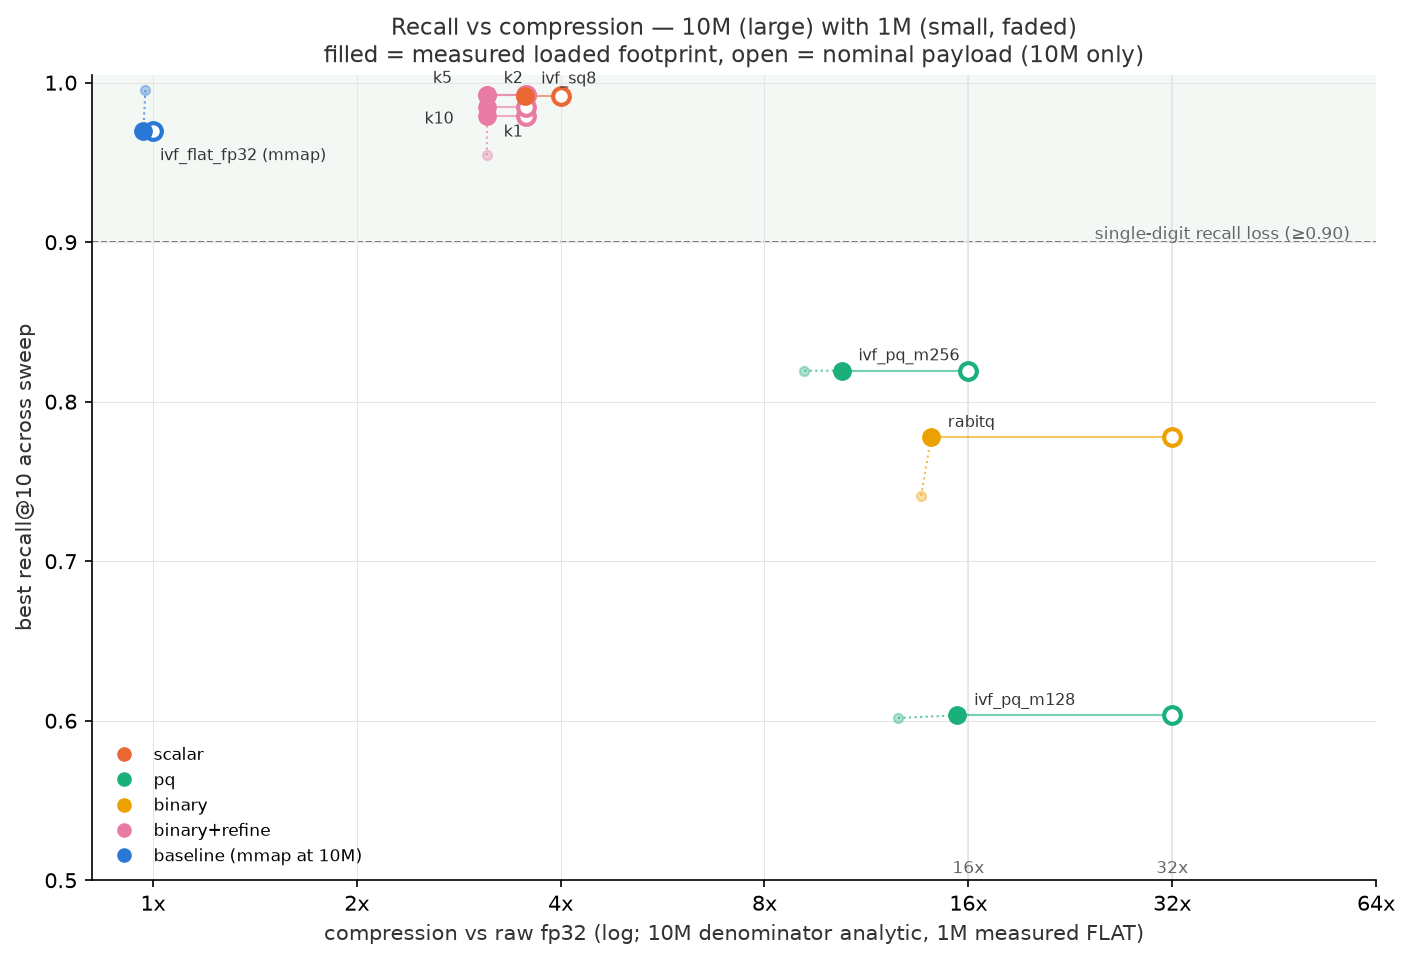

In [20]:
# ---- chart: recall vs compression, 1M + 10M overlay -------------------------
# 10M: open marker = nominal payload, filled = measured footprint (analytic
# raw-fp32 denominator). 1M: small faded filled markers (measured-FLAT
# denominator, from the committed curves_1m.csv), dotted line joins the two
# scales per arm. Family colors as in the 1M chart.
curves_1m_csv = pd.read_csv(RESULTS_WS2 / "curves_1m.csv")

best_10 = (curves_10.groupby("arm", sort=False)
           .apply(lambda g: g.loc[g.recall_at_10.idxmax()],
                  include_groups=False).reset_index())
best_1m = (curves_1m_csv.groupby("arm", sort=False)
           .apply(lambda g: g.loc[g.recall_at_10.idxmax()],
                  include_groups=False).reset_index())
best_1m = best_1m[best_1m.arm.isin(set(best_10.arm))]

fig, ax = plt.subplots(figsize=(9.5, 6.5), dpi=150)
ax.axhspan(0.90, 1.005, color="#f4f8f4", zorder=0)
ax.axhline(0.90, color=INK2, lw=0.8, ls="--", zorder=1)
ax.text(0.98, 0.902, "single-digit recall loss (≥0.90)", ha="right",
        color=INK2, fontsize=8, transform=ax.get_yaxis_transform())
for x in (16, 32):
    ax.axvline(x, color=GRID, lw=0.8, zorder=1)
    ax.text(x, 0.502, f"{x}x", ha="center", va="bottom", color=INK2,
            fontsize=8)

OFFSETS_10 = {"ivf_sq8": (8, 6), "ivf_flat_fp32": (8, -14),
              "rabitq_refine_sq8_k1": (8, -10), "rabitq_refine_sq8_k2": (8, 6),
              "rabitq_refine_sq8_k5": (-26, 6),
              "rabitq_refine_sq8_k10": (-30, -8)}
for _, r in best_10.iterrows():
    c = FAMILY_COLOR[arm_family(r.arm)]
    fp10 = r.footprint_compression_vs_raw_fp32
    m1 = best_1m[best_1m.arm == r.arm]
    if len(m1):
        fp1 = m1.iloc[0].footprint_compression_vs_flat
        ax.plot([fp1, fp10], [m1.iloc[0].recall_at_10, r.recall_at_10],
                ls=":", color=c, lw=1, alpha=0.7, zorder=2)
        ax.plot(fp1, m1.iloc[0].recall_at_10, "o", color=c, ms=4.5,
                alpha=0.35, zorder=3)
    ax.plot([r.payload_compression, fp10], [r.recall_at_10] * 2,
            color=c, lw=1, alpha=0.6, zorder=2)
    ax.plot(r.payload_compression, r.recall_at_10, "o", mfc="white",
            mec=c, ms=8, mew=2, zorder=3)
    ax.plot(fp10, r.recall_at_10, "o", color=c, ms=8, zorder=4)
    label = LABELS.get(r.arm, r.arm) + (" (mmap)" if r.mmap else "")
    ax.annotate(label, (fp10, r.recall_at_10), textcoords="offset points",
                xytext=OFFSETS_10.get(r.arm, (8, 5)), fontsize=7.5,
                color=INK)

ax.set_xscale("log", base=2)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64])
ax.set_xticklabels([f"{t}x" for t in [1, 2, 4, 8, 16, 32, 64]])
ax.set_xlabel("compression vs raw fp32 (log; 10M denominator analytic, "
              "1M measured FLAT)", color=INK)
ax.set_ylabel("best recall@10 across sweep", color=INK)
ax.set_ylim(0.5, 1.005)
ax.set_title("Recall vs compression — 10M (large) with 1M (small, faded)\n"
             "filled = measured loaded footprint, open = nominal payload "
             "(10M only)", color=INK, fontsize=11)
ax.grid(True, color=GRID, lw=0.5, zorder=0)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=f)
           for f, c in FAMILY_COLOR.items() if f != "baseline"]
handles.append(plt.Line2D([], [], marker="o", ls="",
                          color=FAMILY_COLOR["baseline"],
                          label="baseline (mmap at 10M)"))
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
chart_overlay_path = RESULTS_WS2 / "chart_recall_vs_compression_1m_10m.png"
fig.savefig(chart_overlay_path)
print(f"wrote {chart_overlay_path.relative_to(REPO_ROOT)}")
plt.show()
